# 1.1. UMAP intuicyjnie: od punktów do fuzzy grafu i mapowania 1D

Ten notebook pełni podobną rolę jak pierwszy notebook o t-SNE: ma pokazać **co algorytm próbuje dopasować**, zanim przejdziemy do pełnego algorytmu.

UMAP można rozumieć bardzo prosto:

> UMAP najpierw buduje lokalny graf sąsiedztwa w danych wejściowych, a potem szuka takiego ułożenia punktów w niższym wymiarze, żeby ten graf był możliwie podobny.

W tym notebooku nie próbujemy jeszcze implementować wszystkich szczegółów biblioteki `umap-learn`. Chcemy zobaczyć główną ideę:

```text
punkty → odległości → kNN → fuzzy graf P → aktualny graf Q → optymalizacja
```

Będziemy pracować na małym przykładzie sześciu punktów, żeby każdą macierz dało się obejrzeć i zinterpretować.


## W tym notebooku zobaczymy

✓ Jak z punktów powstaje macierz odległości.

✓ Jak UMAP wybiera lokalnych sąsiadów przez graf kNN.

✓ Czym są parametry lokalne $\rho_i$ i $\sigma_i$.

✓ Jak powstaje kierunkowa macierz podobieństw.

✓ Jak kierunkowe podobieństwa łączą się w symetryczny fuzzy graf $P$.

✓ Jak punkty są przesuwane w 1D, aby aktualny graf $Q$ przypominał docelowy graf $P$.


## Obiekty matematyczne

Wejście:

✓ Punkty danych $X$

Budujemy:

✓ Macierz odległości $D$

✓ Graf najbliższych sąsiadów kNN

✓ Kierunkowe podobieństwa $p_{j|i}$

✓ Symetryczny fuzzy graf $P$

Wynik:

✓ Nowe współrzędne punktów w 1D

Ważne: to nie jest klasyczne rzutowanie punktów na prostą. UMAP tworzy nowe współrzędne przez optymalizację grafu sąsiedztwa.


## Do jakiej rodziny należy metoda?

PCA:
→ metody projekcyjne

t-SNE:
→ metody podobieństw

UMAP:
→ metody grafowe

KNN:
→ metody sąsiedztwa

DBSCAN:
→ metody gęstościowe

KMeans:
→ metody centroidowe

LDA:
→ metody dyskryminacyjne

SVM:
→ metody maksymalnego marginesu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from IPython.display import display, HTML, IFrame
from pathlib import Path

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = 'notebook'
np.set_printoptions(precision=3, suppress=True)


## 1. Dane: sześć punktów w dwóch lokalnych grupach

Zaczynamy od bardzo małego przykładu.

Mamy sześć punktów opisanych dwiema cechami:

- $A, B, C$ tworzą jedną lokalną grupę,
- $D, E, F$ tworzą drugą lokalną grupę.

Kolory służą wyłącznie do czytelności wykresu. Algorytm UMAP nie zna kolorów ani etykiet grup. Widzi tylko współrzędne punktów i wynikające z nich odległości.


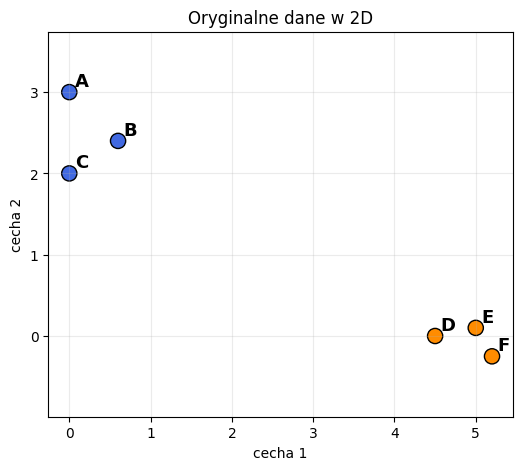

,cecha_1,cecha_2
A,0.0,3.00
B,0.6,2.40
C,0.0,2.00
D,4.5,0.00
E,5.0,0.10
F,5.2,-0.25


In [2]:
labels_umap = np.array(list('ABCDEF'))

X_umap = np.array([
    [0.0, 3.0],   # A
    [0.6, 2.4],   # B
    [0.0, 2.0],   # C
    [4.5, 0.0],   # D
    [5.0, 0.1],   # E
    [5.2, -0.25], # F
])

# Kolory są tylko pomocą wizualną: A,B,C to jedna grupa, D,E,F druga.
colors_umap = np.array([
    'royalblue', 'royalblue', 'royalblue',
    'darkorange', 'darkorange', 'darkorange'
])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_umap[:, 0], X_umap[:, 1], s=120, c=colors_umap, edgecolor='k')
for label, x, y in zip(labels_umap, X_umap[:, 0], X_umap[:, 1]):
    ax.text(x + 0.07, y + 0.07, label, fontsize=13, weight='bold')

ax.set_title('Oryginalne dane w 2D')
ax.set_xlabel('cecha 1')
ax.set_ylabel('cecha 2')
ax.axis('equal')
ax.grid(True, alpha=0.25)
plt.show()

display(
    pd.DataFrame(
        X_umap,
        index=labels_umap,
        columns=['cecha_1', 'cecha_2']
    )
)


## Co próbujemy osiągnąć?

Na początku punkty są opisane przez dwie cechy, więc możemy je narysować w 2D.

W tym notebooku zredukujemy je do 1D, czyli umieścimy wszystkie punkty na jednej osi.

Nie chcemy jednak zachować dokładnych współrzędnych. Chcemy zachować informację o tym:

- które punkty są lokalnymi sąsiadami,
- które punkty tworzą silne połączenia w grafie,
- które punkty powinny pozostać blisko po redukcji wymiarowości.

Innymi słowy: chcemy, aby grupa $A,B,C$ oraz grupa $D,E,F$ pozostały rozdzielone także po przejściu do 1D.


## 2. Macierz odległości

Pierwszy krok UMAP-a jest bardzo prosty: liczymy odległości między punktami.

Macierz $D$ odpowiada na pytanie:

> jak daleko od siebie są punkty $i$ oraz $j$ w oryginalnej przestrzeni cech?

UMAP nie zachowa później całej tej macierzy. Zamiast tego wybierze tylko lokalnych sąsiadów i zbuduje z nich graf.


In [3]:
D_umap = pairwise_distances(X_umap)
pd.DataFrame(D_umap, index=labels_umap, columns=labels_umap).round(2)

,A,B,C,D,E,F
A,0.00,0.85,1.00,5.41,5.78,6.13
B,0.85,0.00,0.72,4.58,4.96,5.31
C,1.00,0.72,0.00,4.92,5.35,5.67
D,5.41,4.58,4.92,0.00,0.51,0.74
E,5.78,4.96,5.35,0.51,0.00,0.40
F,6.13,5.31,5.67,0.74,0.40,0.00


### Które punkty są naprawdę blisko?

Sama macierz odległości bywa trudna do czytania. Dlatego wypiszmy kilka najbliższych par punktów.

To jest most między wykresem punktów a grafem kNN:

```text
mała odległość → kandydat na sąsiada → silna krawędź w grafie
```


In [4]:
pairs = []

for i in range(len(labels_umap)):
    for j in range(i + 1, len(labels_umap)):
        pairs.append({
            'punkt A': labels_umap[i],
            'punkt B': labels_umap[j],
            'odległość': D_umap[i, j]
        })

df_pairs_umap = pd.DataFrame(pairs).sort_values('odległość')
display(df_pairs_umap.head(8).round(3))


,punkt A,punkt B,odległość
14,E,F,0.403
12,D,E,0.510
5,B,C,0.721
13,D,F,0.743
0,A,B,0.849
1,A,C,1.000
6,B,D,4.579
9,C,D,4.924


## 3. Wybieramy `k` najbliższych sąsiadów

W UMAP parametr `n_neighbors = k` mówi, ilu lokalnych kandydatów na sąsiadów rozważamy dla każdego punktu.

Tutaj ustawiamy:

$$
k=3
$$

Dla każdego punktu wybieramy trzech najbliższych sąsiadów.

To jest ważny moment: UMAP zaczyna zachowywać się jak metoda grafowa. Zamiast traktować wszystkie pary punktów tak samo, skupia się głównie na lokalnych połączeniach.


In [5]:
k = 3
knn_idx = np.argsort(D_umap, axis=1)[:, 1:k+1]
knn_dist = np.take_along_axis(D_umap, knn_idx, axis=1)

rows = []
for i, lab in enumerate(labels_umap):
    for rank in range(k):
        rows.append({
            'punkt': lab,
            'rank sąsiada': rank + 1,
            'sąsiad': labels_umap[knn_idx[i, rank]],
            'odległość': knn_dist[i, rank]
        })

pd.DataFrame(rows).round(3)

,punkt,rank sąsiada,sąsiad,odległość
0,A,1,B,0.849
1,A,2,C,1.000
2,A,3,D,5.408
3,B,1,C,0.721
4,B,2,A,0.849
5,B,3,D,4.579
6,C,1,B,0.721
7,C,2,A,1.000
8,C,3,D,4.924
9,D,1,E,0.510


## 4. `rho_i`: najbliższy sąsiad ma dostać wagę 1

UMAP używa lokalnej poprawki:

$$
\rho_i = \min_{j \in kNN(i)} d(x_i,x_j)
$$

czyli $\rho_i$ jest odległością od punktu $i$ do jego najbliższego sąsiada.

Potem we wzorze pojawia się:

$$
\max(0, d(x_i,x_j)-\rho_i)
$$

Dzięki temu najbliższy sąsiad dostaje similarity score równy 1.

Intuicyjnie: każdy punkt powinien mieć przynajmniej jedno bardzo silne połączenie z lokalnym sąsiadem. To jest tzw. lokalna spójność grafu.


In [6]:
rho = knn_dist[:, 0]
pd.DataFrame({'punkt': labels_umap, 'rho_i': rho}).round(3)

,punkt,rho_i
0,A,0.849
1,B,0.721
2,C,0.721
3,D,0.510
4,E,0.403
5,F,0.403


## 5. Po co `sigma_i` i dlaczego pojawia się `log₂(k)`?

Dla punktu $i$ podobieństwo do sąsiada $j$ liczymy jako:

$$
p_{j|i}=\exp\left(-\frac{\max(0, d(x_i,x_j)-\rho_i)}{\sigma_i}\right)
$$

gdzie:

- $d(x_i,x_j)$ — odległość między punktami $i$ oraz $j$,
- $\rho_i$ — odległość do najbliższego sąsiada punktu $i$,
- $\sigma_i$ — lokalna skala odległości wokół punktu $i$,
- $p_{j|i}$ — kierunkowe podobieństwo: jak silnie punkt $i$ łączy się z punktem $j$.

Warto zauważyć różnicę względem t-SNE:

- t-SNE używa lokalnego Gaussa i prawdopodobieństw,
- UMAP używa lokalnego wykładniczego spadku i interpretuje wynik jako siłę krawędzi w fuzzy grafie.

`sigma_i` nie jest regularyzacją. To lokalna skala. Mówi, jak szybko podobieństwo spada, gdy oddalamy się od punktu $i$.

UMAP dobiera `sigma_i` tak, żeby suma wag sąsiadów była bliska:

$$
\sum_{j \in kNN(i)} p_{j|i}\approx \log_2(k)
$$

To nie jest magiczna redukcja wymiaru. To jest kalibracja lokalnej skali.

Dla `k=3`:

$$
\log_2(3) \approx 1.585
$$

Ponieważ najbliższy sąsiad ma wagę 1, zostaje około `0.585` masy podobieństwa na pozostałych sąsiadów. Dzięki temu graf jest lokalny, ale nie zupełnie twardy.


In [7]:
target_sum = np.log2(k)
print('k =', k)
print('log2(k) =', target_sum)

k = 3
log2(k) = 1.584962500721156


## 6. Dobieramy `sigma_i` i liczymy kierunkowe podobieństwa

Dla każdego punktu robimy małe wyszukiwanie binarne: szukamy takiego `sigma_i`, żeby suma similarity dla jego `k` sąsiadów była bliska `log₂(k)`.

Można o tym myśleć tak:

- punkt w gęstym obszarze dostaje mniejsze `sigma_i`,
- punkt w rzadkim obszarze dostaje większe `sigma_i`.

Dzięki temu każdy punkt ma własną lokalną skalę sąsiedztwa.


In [8]:
def find_umap_sigma(distances_to_neighbors, rho_i, target_sum, tol=1e-5, max_iter=80):
    lo, hi = 1e-4, 1000.0
    distances_to_neighbors = np.asarray(distances_to_neighbors)

    for _ in range(max_iter):
        mid = (lo + hi) / 2
        scores = np.exp(-np.maximum(0, distances_to_neighbors - rho_i) / mid)
        score_sum = scores.sum()
        if abs(score_sum - target_sum) < tol:
            return mid
        if score_sum > target_sum:
            hi = mid
        else:
            lo = mid
    return (lo + hi) / 2

n = len(X_umap)
sigmas = np.zeros(n)
P_directed = np.zeros((n, n))

for i in range(n):
    sigmas[i] = find_umap_sigma(knn_dist[i], rho[i], target_sum)
    scores = np.exp(-np.maximum(0, knn_dist[i] - rho[i]) / sigmas[i])
    P_directed[i, knn_idx[i]] = scores

pd.DataFrame({
    'punkt': labels_umap,
    'rho_i': rho,
    'sigma_i': sigmas,
    'suma similarity': P_directed.sum(axis=1),
    'cel log2(k)': target_sum,
}).round(4)

,punkt,rho_i,sigma_i,suma similarity,cel log2(k)
0,A,0.8485,0.2825,1.585,1.585
1,B,0.7211,0.2376,1.585,1.585
2,C,0.7211,0.5196,1.585,1.585
3,D,0.5099,0.4352,1.585,1.585
4,E,0.4031,0.1992,1.585,1.585
5,F,0.4031,0.6336,1.585,1.585


## 7. Kierunkowa macierz similarity

Macierz kierunkowa nie musi być symetryczna.

To znaczy:

$$
p_{j|i} \neq p_{i|j}
$$

Podobieństwo `A → C` może być inne niż `C → A`, bo każdy punkt ma własne $\rho_i$ i $\sigma_i$.

To bardzo ważne: na tym etapie nie mamy jeszcze jednego zwykłego grafu. Mamy lokalne, kierunkowe oceny sąsiedztwa.


In [9]:
pd.DataFrame(P_directed, index=labels_umap, columns=labels_umap).round(3)

,A,B,C,D,E,F
A,0.000,1.0,0.585,0.000,0.0,0.000
B,0.585,0.0,1.000,0.000,0.0,0.000
C,0.585,1.0,0.000,0.000,0.0,0.000
D,0.000,0.0,0.000,0.000,1.0,0.585
E,0.000,0.0,0.000,0.585,0.0,1.000
F,0.000,0.0,0.000,0.585,1.0,0.000


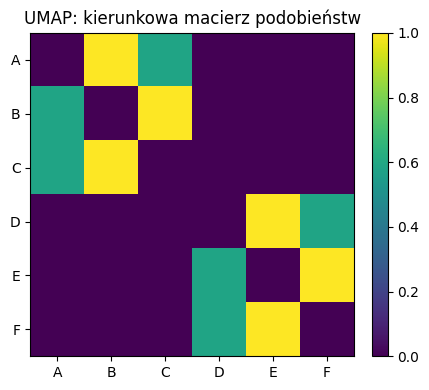

In [10]:
def plot_matrix(M, title, labels, vmin=0, vmax=1, figsize=(5, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(M, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig, ax

plot_matrix(P_directed, 'UMAP: kierunkowa macierz podobieństw', labels_umap, vmin=0, vmax=1);

## 8. Symetryzacja: fuzzy union

UMAP potrzebuje jednego grafu nieskierowanego. Łączy więc `p_{j|i}` i `p_{i|j}` regułą fuzzy union:

$$
p_{ij}=p_{j|i}+p_{i|j}-p_{j|i}p_{i|j}
$$

gdzie:

- $p_{j|i}$ — siła połączenia z punktu $i$ do punktu $j$,
- $p_{i|j}$ — siła połączenia z punktu $j$ do punktu $i$,
- $p_{ij}$ — finalna, symetryczna siła krawędzi w fuzzy grafie.

Intuicja:

> jeśli przynajmniej jeden kierunek mówi „to jest mocne sąsiedztwo”, to krawędź powinna pozostać mocna.

To jest odpowiednik przejścia od lokalnych opinii punktów do jednego wspólnego grafu sąsiedztwa.


In [11]:
P_umap = P_directed + P_directed.T - P_directed * P_directed.T
np.fill_diagonal(P_umap, 0.0)

pd.DataFrame(P_umap, index=labels_umap, columns=labels_umap).round(3)

,A,B,C,D,E,F
A,0.000,1.0,0.828,0.000,0.0,0.000
B,1.000,0.0,1.000,0.000,0.0,0.000
C,0.828,1.0,0.000,0.000,0.0,0.000
D,0.000,0.0,0.000,0.000,1.0,0.828
E,0.000,0.0,0.000,1.000,0.0,1.000
F,0.000,0.0,0.000,0.828,1.0,0.000


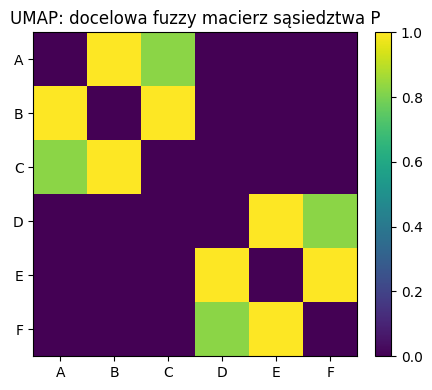

In [12]:
plot_matrix(P_umap, 'UMAP: docelowa fuzzy macierz sąsiedztwa P', labels_umap, vmin=0, vmax=1);

## 9. Aktualna macierz w przestrzeni 1D

Teraz próbujemy ułożyć punkty na jednej linii.

Każdy punkt dostaje nową współrzędną:

$$
y_i
$$

Dla aktualnego ułożenia `y` liczymy niskowymiarowe podobieństwo:

$$
q_{ij}=\frac{1}{1+\lVert y_i-y_j\rVert^2}
$$

To jest uproszczona wersja krzywej używanej przez UMAP w niskim wymiarze.

Interpretacja:

- blisko na linii → $q_{ij}$ duże,
- daleko na linii → $q_{ij}$ małe.

Ważne: to nie jest rzutowanie jak w PCA. Punkty dostają nowe współrzędne, które są zmieniane przez optymalizację.


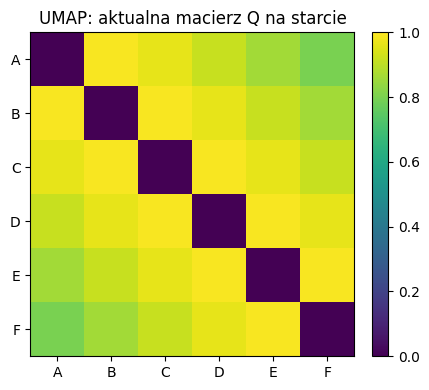

In [13]:
def umap_lowdim_Q_1d(y):
    diff = y[:, None] - y[None, :]
    Q = 1.0 / (1.0 + diff ** 2)
    np.fill_diagonal(Q, 0.0)
    return Q


def umap_bce_loss_grad_1d(y, P):
    """Dydaktyczna pełna binary cross-entropy dla wszystkich par i<j."""
    diff = y[:, None] - y[None, :]
    Q = 1.0 / (1.0 + diff ** 2)
    np.fill_diagonal(Q, 0.0)

    eps = 1e-6
    loss = 0.0
    grad = np.zeros_like(y)
    n = len(y)

    for i in range(n):
        for j in range(i + 1, n):
            p = P[i, j]
            q = np.clip(Q[i, j], eps, 1 - eps)
            loss += -(p * np.log(q) + (1 - p) * np.log(1 - q))

            dL_dq = -p / q + (1 - p) / (1 - q)
            dq_dyi = -2 * diff[i, j] / (1 + diff[i, j] ** 2) ** 2
            g = dL_dq * dq_dyi
            grad[i] += g
            grad[j] -= g

    return loss, grad, Q

# start: punkty są prawie na jednej krótkiej linii, więc Q jest początkowo za gęste
initial_y_umap = np.array([-0.20, -0.10, 0.00, 0.10, 0.20, 0.30])
Q_start = umap_lowdim_Q_1d(initial_y_umap)
plot_matrix(Q_start, 'UMAP: aktualna macierz Q na starcie', labels_umap, vmin=0, vmax=1);

## 10. Optymalizacja: dopasowujemy `Q` do `P`

W tym momencie mamy dwa obiekty:

- $P$ — docelowy fuzzy graf zbudowany w oryginalnej przestrzeni cech,
- $Q$ — aktualny fuzzy graf wynikający z położeń punktów w 1D.

UMAP przesuwa punkty tak, aby $Q$ coraz bardziej przypominało $P$.

UMAP w praktyce robi stochastyczną optymalizację z dodatnimi i ujemnymi przykładami krawędzi. Tu pokazujemy wersję dydaktyczną: pełną binary cross-entropy dla wszystkich par.

Interpretacja:

- jeśli $P_{ij}$ jest duże, chcemy zwiększyć $Q_{ij}$, czyli przyciągnąć punkty,
- jeśli $P_{ij}$ jest małe, chcemy zmniejszyć $Q_{ij}$, czyli odsunąć punkty.

Zapisujemy kolejne klatki optymalizacji.


In [14]:
def run_umap_1d_path(P, y0, n_steps=100, record_every=1):
    y = y0.astype(float).copy()
    y = y - y.mean()
    velocity = np.zeros_like(y)
    frames = []

    for t in range(n_steps + 1):
        loss, grad, Q = umap_bce_loss_grad_1d(y, P)
        if t % record_every == 0:
            frames.append({'iter': t, 'y': y.copy(), 'Q': Q.copy(), 'loss': float(loss)})

        lr = 0.05 / (1 + t / 500)
        momentum = 0.5
        velocity = momentum * velocity - lr * grad
        y = y + velocity
        y = y - y.mean()

    return frames

frames_umap = run_umap_1d_path(P_umap, initial_y_umap)
print(f'Liczba zapisanych klatek: {len(frames_umap)}')
print(f'Loss start: {frames_umap[0]["loss"]:.4f}')
print(f'Loss koniec: {frames_umap[-1]["loss"]:.4f}')

Liczba zapisanych klatek: 101
Loss start: 25.4109
Loss koniec: 1.3540


## 11. Interaktywny suwak: docelowe `P`, aktualne `Q` i punkty na linii

Animacja pokazuje trzy rzeczy:

1. **Docelowy graf $P$** — to, co UMAP zbudował z danych wejściowych.
2. **Aktualny graf $Q$** — to, co wynika z obecnego ułożenia punktów w 1D.
3. **Pozycje punktów w 1D** — parametry, które algorytm zmienia.

Przesuwaj suwak. Patrz, czy aktualna macierz `Q` coraz bardziej przypomina docelową fuzzy macierz `P`.

W tym przykładzie UMAP powinien wytworzyć dwie lokalne grupy:

```text
A-B-C        D-E-F
```

czyli zachować lokalną strukturę grafu sąsiedztwa.


In [15]:
def make_umap_slider_figure(frames, P, labels, colors, html_path=None):
    """
    Tworzy interaktywny panel UMAP-like.

    Wersja poprawiona pod renderowanie w Jupyterze:
    - nie polega na CDN,
    - zapisuje pełny HTML z osadzonym Plotly JS,
    - wyświetla panel przez IFrame,
    - w animacji aktualizuje tylko Q i pozycje punktów; P zostaje stałe.
    """
    fig = make_subplots(
        rows=1,
        cols=3,
        subplot_titles=(
            'Docelowa fuzzy macierz P',
            'Aktualna macierz Q',
            'Pozycje punktów w 1D'
        ),
        specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}, {'type': 'scatter'}]],
        column_widths=[0.32, 0.32, 0.36]
    )

    first = frames[0]
    global_span = max(
        1.0,
        max(float(np.max(np.abs(f['y']))) for f in frames) * 1.15
    )

    # 0. Stała macierz docelowa P.
    fig.add_trace(
        go.Heatmap(
            z=P,
            x=labels,
            y=labels,
            zmin=0,
            zmax=1,
            colorscale='Viridis',
            colorbar=dict(title='P/Q', x=0.30)
        ),
        row=1,
        col=1
    )

    # 1. Aktualna macierz Q dla pierwszej iteracji.
    fig.add_trace(
        go.Heatmap(
            z=first['Q'],
            x=labels,
            y=labels,
            zmin=0,
            zmax=1,
            colorscale='Viridis',
            showscale=False
        ),
        row=1,
        col=2
    )

    # 2. Aktualne pozycje punktów w 1D.
    fig.add_trace(
        go.Scatter(
            x=first['y'],
            y=np.zeros(len(labels)),
            mode='markers+text',
            text=labels,
            textposition='top center',
            marker=dict(
                size=18,
                color=colors,
                line=dict(color='black', width=1)
            ),
            showlegend=False
        ),
        row=1,
        col=3
    )

    plotly_frames = []
    for f in frames:
        plotly_frames.append(
            go.Frame(
                name=str(f['iter']),
                # Aktualizujemy tylko trace 1 i trace 2.
                # Trace 0, czyli P, jest stały i nie musi być przerysowywany.
                traces=[1, 2],
                data=[
                    go.Heatmap(
                        z=f['Q'],
                        x=labels,
                        y=labels,
                        zmin=0,
                        zmax=1,
                        colorscale='Viridis',
                        showscale=False
                    ),
                    go.Scatter(
                        x=f['y'],
                        y=np.zeros(len(labels)),
                        mode='markers+text',
                        text=labels,
                        textposition='top center',
                        marker=dict(
                            size=18,
                            color=colors,
                            line=dict(color='black', width=1)
                        ),
                        showlegend=False
                    )
                ],
                layout=go.Layout(
                    title_text=f'UMAP-like 1D: iteracja {f["iter"]}, loss = {f["loss"]:.4f}'
                )
            )
        )

    fig.frames = plotly_frames

    steps = [
        dict(
            method='animate',
            args=[
                [str(f['iter'])],
                dict(
                    mode='immediate',
                    frame=dict(duration=0, redraw=True),
                    transition=dict(duration=0)
                )
            ],
            label=str(f['iter'])
        )
        for f in frames
    ]

    fig.update_layout(
        title=f'UMAP-like 1D: iteracja {first["iter"]}, loss = {first["loss"]:.4f}',
        height=540,
        width=1150,
        sliders=[
            dict(
                active=0,
                currentvalue={'prefix': 'Iteracja: '},
                pad={'t': 50},
                steps=steps
            )
        ],
        updatemenus=[
            dict(
                type='buttons',
                showactive=False,
                y=1.13,
                x=0.0,
                xanchor='left',
                yanchor='top',
                buttons=[
                    dict(
                        label='▶ Play',
                        method='animate',
                        args=[
                            None,
                            dict(
                                frame=dict(duration=120, redraw=True),
                                transition=dict(duration=0),
                                fromcurrent=True,
                                mode='immediate'
                            )
                        ]
                    ),
                    dict(
                        label='⏸ Stop',
                        method='animate',
                        args=[
                            [None],
                            dict(
                                frame=dict(duration=0, redraw=False),
                                transition=dict(duration=0),
                                mode='immediate'
                            )
                        ]
                    )
                ]
            )
        ]
    )

    fig.update_xaxes(tickangle=0, row=1, col=1)
    fig.update_xaxes(tickangle=0, row=1, col=2)
    fig.update_yaxes(autorange='reversed', row=1, col=1)
    fig.update_yaxes(autorange='reversed', row=1, col=2)
    fig.update_yaxes(range=[-1, 1], showticklabels=False, row=1, col=3)
    fig.update_xaxes(range=[-global_span, global_span], title='pozycja na linii', row=1, col=3)

    if html_path is not None:
        fig.write_html(
            str(html_path),
            include_plotlyjs=True,  # ważne: nie CDN, tylko pełny JS w pliku
            full_html=True,
            auto_play=False
        )

    return fig


html_dir = Path('html')
html_dir.mkdir(parents=True, exist_ok=True)
html_path = html_dir / '1_1_umap_interaktywny_slider.html'

fig_umap = make_umap_slider_figure(
    frames_umap,
    P_umap,
    labels_umap,
    colors_umap,
    html_path=html_path
)

# Najstabilniejszy sposób wyświetlania w notebooku:
# 1. zapisujemy kompletny HTML,
# 2. osadzamy go jako IFrame.
display(IFrame(src=str(html_path), width=1170, height=610))

# Link awaryjny: jeśli IFrame nie pokaże panelu, otwórz plik HTML w osobnej karcie.
display(HTML(f'<p><a href="{html_path.as_posix()}" target="_blank">Otwórz interaktywny panel UMAP w osobnej karcie</a></p>'))

## 12. Najważniejsza intuicja

UMAP robi trzy rzeczy:

1. **Buduje lokalny graf sąsiedztw** w przestrzeni wejściowej.
2. **Zamienia odległości na fuzzy similarity score**, czyli siłę krawędzi.
3. **Przesuwa punkty w niskim wymiarze**, żeby aktualny graf $Q$ przypominał docelowy graf $P$.

Najkrótsze podsumowanie:

```text
UMAP nie próbuje zachować wszystkich odległości.
UMAP próbuje zachować lokalny graf sąsiedztwa.
```

`log₂(k)` nie zmniejsza wymiaru. Ono służy tylko do dobrania lokalnej skali `sigma_i`.

Redukcja wymiaru dzieje się dopiero w optymalizacji, gdy punkty są przesuwane w 1D lub 2D.

Wersja UMAP różni się od t-SNE głównie tym, że zaczyna od lokalnego fuzzy grafu kNN, a t-SNE zaczyna od macierzy prawdopodobieństw sąsiedztwa.


## Co warto zapamiętać?

✓ UMAP jest metodą grafową.

✓ Najpierw buduje lokalny graf kNN w oryginalnych danych.

✓ $\rho_i$ zapewnia, że każdy punkt ma przynajmniej jedno silne lokalne połączenie.

✓ $\sigma_i$ jest lokalną skalą odległości, a nie klasyczną regularyzacją.

✓ Fuzzy union zamienia kierunkowe podobieństwa w jeden symetryczny graf $P$.

✓ Optymalizacja przesuwa punkty tak, aby graf $Q$ w niskim wymiarze przypominał graf $P$.

✓ UMAP zachowuje głównie lokalną strukturę sąsiedztwa, a nie dokładne odległości globalne.
